# Notebook 01 — Visualización de la Sierra Nevada de Santa Marta

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/miguepoloc/teledeteccion/blob/main/sesiones/sesion-01/docente/colab/01_visualizacion_snsm.ipynb)

## Maestría en Ingeniería — Universidad del Magdalena
### Sesión 1: Fundamentos de Teledetección

---

**¿Para qué sirve este notebook?**  
El docente mostró en clase la SNSM en color natural y falso color usando GEE Code Editor (JavaScript).
Este notebook reproduce exactamente lo mismo en Python para que puedas repetirlo en casa y entender cada línea de código.

**Lo que aprenderás:**
- Cargar una imagen Sentinel-2 desde GEE en Python
- Diferencia entre color natural, falso color NIR y composición SWIR
- Por qué la vegetación aparece **roja** en el falso color NIR
- Leer los valores de reflectancia de un pixel y graficar la firma espectral

**Tiempo estimado:** 20–30 minutos

**Referencias:**
- Drusch, M. et al. (2012). Sentinel-2: ESA's Optical High-Resolution Mission for GMES. *RSE*, 120, 25–36. DOI: 10.1016/j.rse.2011.11.026
- Chuvieco, E. (2016). *Fundamentals of Satellite Remote Sensing* (2nd ed.). CRC Press.
- Jacquemoud, S. & Baret, F. (1990). PROSPECT. *RSE*, 34(2), 75–91. DOI: 10.1016/0034-4257(90)90100-Z

In [1]:
# Instalar paquetes (solo la primera vez en Colab)
!pip install earthengine-api geemap -q

zsh:1: command not found: pip


In [2]:
import ee
import geemap

# Autenticar con Google Earth Engine
# La primera vez abrirá una ventana del navegador para iniciar sesión
try:
    ee.Initialize(project='teledeteccion-miguepoloc')  # Cambia por tu proyecto GEE
except Exception:
    ee.Authenticate()
    ee.Initialize(project='teledeteccion-miguepoloc')

print('GEE listo')

GEE listo


## Paso 1 — Definir las zonas de estudio

In [3]:
norte_magdalena = ee.Geometry.Rectangle([-74.5, 10.2, -73.2, 11.2])
zona_cacaotera  = ee.Geometry.Rectangle([-74.2, 10.5, -73.8, 11.0])
snsm = ee.Geometry.Polygon([[[-74.2, 11.0], [-73.6, 11.3], [-73.0, 10.8], [-73.5, 10.4], [-74.1, 10.5]]])

print('Zonas definidas')

Zonas definidas


## Paso 2 — Cargar Sentinel-2 L2A (Surface Reflectance)

Usamos **L2A** porque ya tiene corrección atmosférica. Los valores van de 0 a 10 000
(un valor de 1000 = 10 % de reflectancia). Período: enero–marzo 2024 (temporada seca).

In [4]:
imagen_2024 = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(norte_magdalena)
    .filterDate('2024-01-01', '2024-03-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .median()   # mediana pixel a pixel → elimina nubes residuales
    .clip(norte_magdalena)
)

n = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
     .filterBounds(norte_magdalena)
     .filterDate('2024-01-01', '2024-03-31')
     .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
     .size().getInfo())

print(f'Imágenes combinadas en la mediana: {n}')

Imágenes combinadas en la mediana: 58


## Paso 3 — Color Natural vs. Falso Color NIR vs. SWIR

| Composición | Canal Rojo (pantalla) | Canal Verde | Canal Azul | Resultado |
|------------|----------------------|------------|-----------|----------|
| Color Natural | B4 (Rojo, 665 nm) | B3 (Verde, 560 nm) | B2 (Azul, 490 nm) | Como el ojo humano |
| Falso Color NIR | **B8 (NIR, 842 nm)** | B4 (Rojo) | B3 (Verde) | Vegetación = rojo brillante |
| Composición SWIR | B11 (SWIR, 1610 nm) | B8 (NIR) | B4 (Rojo) | Humedad y coberturas |

**Activa y desactiva capas en el panel de la derecha del mapa para comparar.**

In [5]:
Map = geemap.Map(center=[10.75, -74.0], zoom=10)

Map.addLayer(imagen_2024,
    {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000, 'gamma': 1.4},
    '1 — Color Natural')

Map.addLayer(imagen_2024,
    {'bands': ['B8', 'B4', 'B3'], 'min': 0, 'max': 4000},
    '2 — Falso Color NIR (B8-B4-B3)', False)

Map.addLayer(imagen_2024,
    {'bands': ['B11', 'B8', 'B4'], 'min': 0, 'max': 4000},
    '3 — Composición SWIR (B11-B8-B4)', False)

Map.addLayer(zona_cacaotera, {'color': 'FF6B00'}, 'Zona Cacaotera')
Map.addLayer(snsm, {'color': '0000FF', 'fillColor': '0000FF10'}, 'SNSM')

Map

Map(center=[10.75, -74.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## Paso 4 — Leer valores de un pixel y graficar la firma espectral

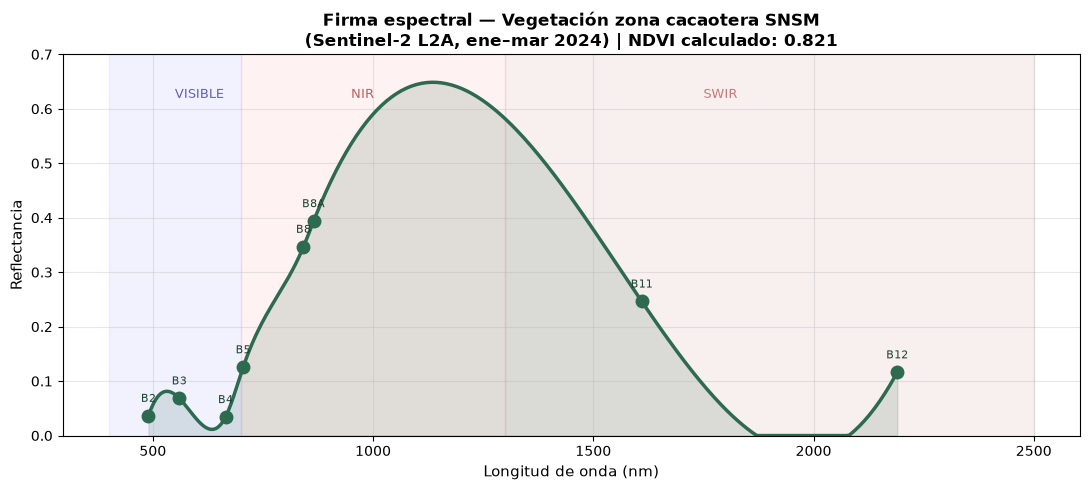

Firma espectral guardada como firma_espectral_vegetacion_snsm.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

punto_cacao = ee.Geometry.Point([-74.0, 10.75])

bandas = ['B2', 'B3', 'B4', 'B5', 'B8', 'B8A', 'B11', 'B12']
nombres = ['Azul\n490nm', 'Verde\n560nm', 'Rojo\n665nm',
           'RedEdge1\n705nm', 'NIR\n842nm', 'NIR estrecho\n865nm',
           'SWIR1\n1610nm', 'SWIR2\n2190nm']
lw_nm   = [490, 560, 665, 705, 842, 865, 1610, 2190]

vals = imagen_2024.select(bandas).reduceRegion(
    reducer=ee.Reducer.mean(), geometry=punto_cacao, scale=10
).getInfo()

refs = [vals.get(b, 0) / 10000 for b in bandas]

# Crear valores x suavizados para graficar la curva continua
lw_suave = np.linspace(min(lw_nm), max(lw_nm), 300)
f_ref = interp1d(lw_nm, refs, kind='cubic')
refs_suave = np.clip(f_ref(lw_suave), 0, None)

fig, ax = plt.subplots(figsize=(11, 5))

# Graficar la línea curva continua y rellenar abajo
ax.plot(lw_suave, refs_suave, color='#2d6a4f', lw=2.5)
ax.fill_between(lw_suave, 0, refs_suave, alpha=0.15, color='#2d6a4f')

# Graficar los puntos originales sobre la curva
ax.plot(lw_nm, refs, 'o', color='#2d6a4f', ms=9)

ax.axvspan(400, 700, alpha=0.05, color='blue')   # visible
ax.axvspan(700, 1300, alpha=0.05, color='red')   # NIR
ax.axvspan(1300, 2500, alpha=0.07, color='brown')# SWIR

ax.text(550, 0.62, 'VISIBLE', fontsize=9, color='navy', alpha=0.6)
ax.text(950, 0.62, 'NIR', fontsize=9, color='darkred', alpha=0.6)
ax.text(1750, 0.62, 'SWIR', fontsize=9, color='brown', alpha=0.6)

for l, r, b in zip(lw_nm, refs, bandas):
    ax.annotate(b, (l, r), xytext=(0, 10), textcoords='offset points',
                fontsize=8, ha='center', color='#1b4332')

ndvi = round((vals['B8'] - vals['B4']) / (vals['B8'] + vals['B4']), 3)
ax.set_title(f'Firma espectral — Vegetación zona cacaotera SNSM\n'
             f'(Sentinel-2 L2A, ene–mar 2024) | NDVI calculado: {ndvi}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Longitud de onda (nm)', fontsize=11)
ax.set_ylabel('Reflectancia', fontsize=11)
ax.set_ylim(0, 0.7)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('firma_espectral_vegetacion_snsm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Firma espectral guardada como firma_espectral_vegetacion_snsm.png')

---

## Preguntas de reflexión

1. ¿Por qué el NIR (B8) tiene reflectancia tan alta en la vegetación? *(pista: estructura del mesófilo esponjoso — Jacquemoud & Baret, 1990)*
2. ¿Qué cambiaría en la firma espectral si la planta estuviera estresada o enferma?
3. ¿Puedes calcular el NDWI = (B8 - B11) / (B8 + B11) con los valores que extraíste?
4. ¿Por qué en la composición SWIR el agua aparece casi negra?

*Documento de uso interno — Sesión 1 — Maestría en Ingeniería, Univ. del Magdalena.*